#### importing packages

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

#### import datasets

In [2]:
os.chdir('//Users//arupranjankhawas//Desktop//AnalytixLabs//Python-Case Study//Retail Case Study')

In [3]:
df_cust = pd.read_csv('Customer.csv')

In [4]:
df_trans = pd.read_csv('Transactions.csv')

In [5]:
df_prod = pd.read_csv('prod_cat_info.csv')

In [6]:
df_cust.head(2)

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0


In [7]:
df_trans.head(2)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop


In [8]:
df_prod.head(2)

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women


#### remane customer_id column

In [9]:
df_cust = df_cust.rename(columns={"customer_Id":"cust_id"})

#### merging customer and transaction datasets

In [10]:
df_cust_trn = pd.merge(
    df_trans,
    df_cust,
    on = "cust_id",
    how="inner"
)

#### merging customer_trn and product datasets

In [11]:
df_cust_final = pd.merge(
    df_cust_trn,
    df_prod,
    on = "prod_cat_code",
    how = "left"
)

In [12]:
df_cust_final.shape

(99293, 16)

In [13]:
df_cust_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99293 entries, 0 to 99292
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     99293 non-null  int64  
 1   cust_id            99293 non-null  int64  
 2   tran_date          99293 non-null  object 
 3   prod_subcat_code   99293 non-null  int64  
 4   prod_cat_code      99293 non-null  int64  
 5   Qty                99293 non-null  int64  
 6   Rate               99293 non-null  int64  
 7   Tax                99293 non-null  float64
 8   total_amt          99293 non-null  float64
 9   Store_type         99293 non-null  object 
 10  DOB                99293 non-null  object 
 11  Gender             99253 non-null  object 
 12  city_code          99257 non-null  float64
 13  prod_cat           99293 non-null  object 
 14  prod_sub_cat_code  99293 non-null  int64  
 15  prod_subcat        99293 non-null  object 
dtypes: float64(3), int64(7

In [14]:
df_cust_final.head(10)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,4,Mens
1,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,1,Women
2,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop,26-09-1981,M,5.0,Clothing,3,Kids
3,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,4,Mobiles
4,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,5,Computers
5,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,8,Personal Appliances
6,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,9,Cameras
7,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop,11-05-1973,F,8.0,Electronics,10,Audio and video
8,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,7,Fiction
9,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop,27-07-1992,M,8.0,Books,12,Academic


In [15]:
df_cust_final.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,99293.0,5.007320e+10,2.899361e+10,3268991.000,2.492150e+10,5.011083e+10,7.528121e+10,9.998755e+10
cust_id,99293.0,2.710300e+05,2.429334e+03,266783.000,2.689560e+05,2.709820e+05,2.731200e+05,2.752650e+05
prod_subcat_code,99293.0,6.796894e+00,3.609439e+00,1.000,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01
prod_cat_code,99293.0,4.003243e+00,1.563991e+00,1.000,3.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00
Qty,99293.0,2.438017e+00,2.260726e+00,-5.000,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Rate,99293.0,6.379199e+02,6.215763e+02,-1499.000,3.130000e+02,7.130000e+02,1.109000e+03,1.500000e+03
Tax,99293.0,2.488737e+02,1.870144e+02,7.350,9.828000e+01,1.999200e+02,3.669750e+02,7.875000e+02
total_amt,99293.0,2.114616e+03,2.502307e+03,-8270.925,7.624500e+02,1.761370e+03,3.585725e+03,8.287500e+03
city_code,99257.0,5.467221e+00,2.859343e+00,1.000,3.000000e+00,5.000000e+00,8.000000e+00,1.000000e+01
prod_sub_cat_code,99293.0,6.806985e+00,3.615952e+00,1.000,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01


In [16]:
df_cust_final.columns

Index(['transaction_id', 'cust_id', 'tran_date', 'prod_subcat_code',
       'prod_cat_code', 'Qty', 'Rate', 'Tax', 'total_amt', 'Store_type', 'DOB',
       'Gender', 'city_code', 'prod_cat', 'prod_sub_cat_code', 'prod_subcat'],
      dtype='object')

In [17]:
df_cust_final.dtypes

transaction_id         int64
cust_id                int64
tran_date             object
prod_subcat_code       int64
prod_cat_code          int64
Qty                    int64
Rate                   int64
Tax                  float64
total_amt            float64
Store_type            object
DOB                   object
Gender                object
city_code            float64
prod_cat              object
prod_sub_cat_code      int64
prod_subcat           object
dtype: object

#### correct datatypes 

In [18]:
df_cust_final['tran_date'] = pd.to_datetime(df_cust_final['tran_date'],  format='mixed', dayfirst=True, errors='coerce')


In [19]:
df_cust_final['DOB'] = pd.to_datetime(df_cust_final['DOB'], format='mixed', dayfirst=True, errors='coerce')

In [20]:
df_cust_final['city_code'] = df_cust_final['city_code'].astype('category')

In [21]:
df_cust_final['city_code'].unique()

[5.0, 8.0, 3.0, 6.0, 9.0, ..., 2.0, 10.0, 7.0, 4.0, NaN]
Length: 11
Categories (10, float64): [1.0, 2.0, 3.0, 4.0, ..., 7.0, 8.0, 9.0, 10.0]

In [22]:
df_cust_final

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,4,Mens
1,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,1,Women
2,80712190438,270351,2014-02-28,1,1,-5,-772,405.300,-4265.300,e-Shop,1981-09-26,M,5.0,Clothing,3,Kids
3,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-05-11,F,8.0,Electronics,4,Mobiles
4,29258453508,270384,2014-02-27,5,3,-5,-1497,785.925,-8270.925,e-Shop,1973-05-11,F,8.0,Electronics,5,Computers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99288,77960931771,271961,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,1982-01-15,M,1.0,Books,12,Academic
99289,77960931771,271961,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,1982-01-15,M,1.0,Books,10,Non-Fiction
99290,77960931771,271961,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,1982-01-15,M,1.0,Books,11,Children
99291,77960931771,271961,2011-01-25,11,5,1,447,46.935,493.935,TeleShop,1982-01-15,M,1.0,Books,3,Comics


In [23]:
cat_cols = df_cust_final.select_dtypes(include=['object','category']).columns

In [24]:
cat_cols.value_counts()

Store_type     1
Gender         1
city_code      1
prod_cat       1
prod_subcat    1
Name: count, dtype: int64

In [25]:
for i in cat_cols:
    print("\nFrequency table for:", i)
    print(df_cust_final[i].value_counts())


Frequency table for: Store_type
Store_type
e-Shop            40185
MBR               19974
Flagship store    19814
TeleShop          19320
Name: count, dtype: int64

Frequency table for: Gender
Gender
M    51051
F    48202
Name: count, dtype: int64

Frequency table for: city_code
city_code
4.0     10571
3.0     10467
7.0     10258
5.0     10116
10.0     9976
8.0      9965
2.0      9843
1.0      9717
9.0      9214
6.0      9130
Name: count, dtype: int64

Frequency table for: prod_cat
prod_cat
Books               36414
Electronics         24490
Home and kitchen    16516
Footwear             8997
Clothing             8880
Bags                 3996
Name: count, dtype: int64

Frequency table for: prod_subcat
prod_subcat
Mens                   7957
Women                  7957
Fiction                6069
DIY                    6069
Comics                 6069
Children               6069
Non-Fiction            6069
Academic               6069
Kids                   5959
Audio and video       

In [26]:
cont_cols = df_cust_final.select_dtypes(include='number').columns

In [27]:
cont_cols

Index(['transaction_id', 'cust_id', 'prod_subcat_code', 'prod_cat_code', 'Qty',
       'Rate', 'Tax', 'total_amt', 'prod_sub_cat_code'],
      dtype='object')

####  Generate histograms for all continuous variables

In [54]:
import os

os.makedirs("images", exist_ok=True)

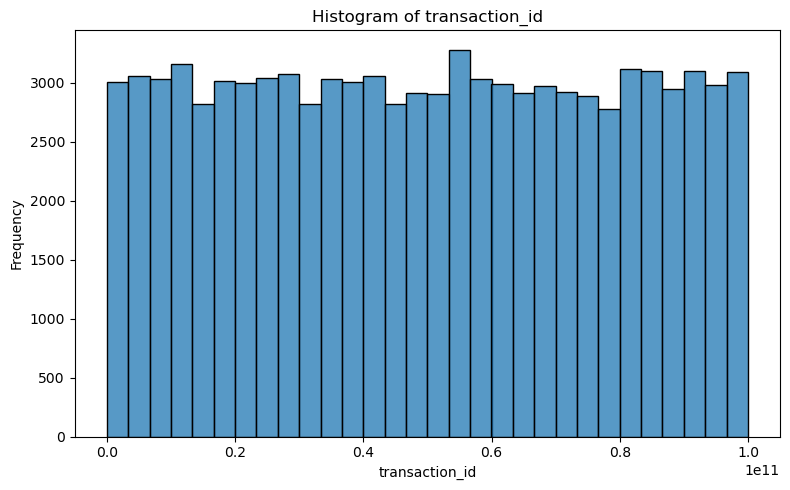

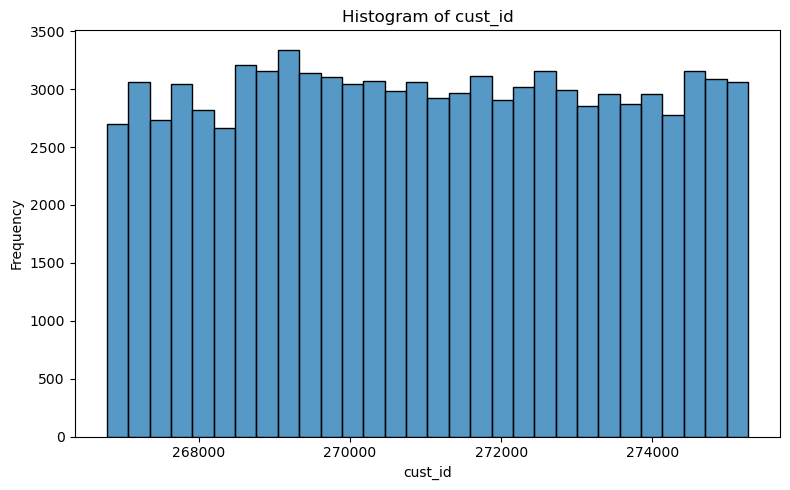

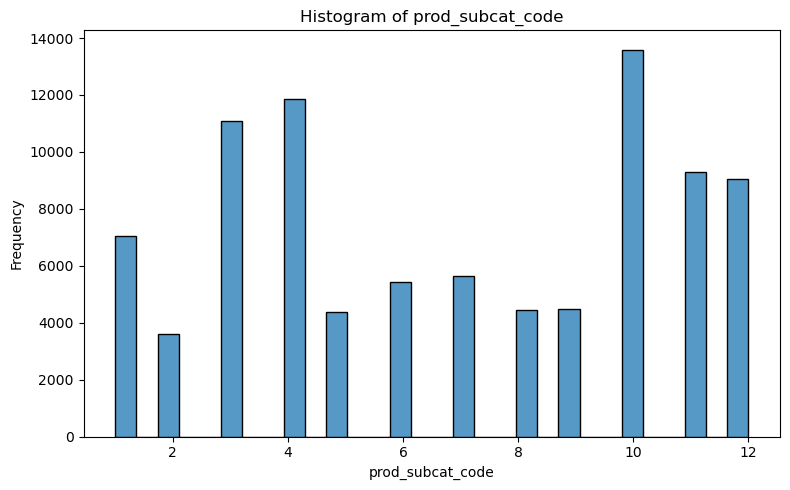

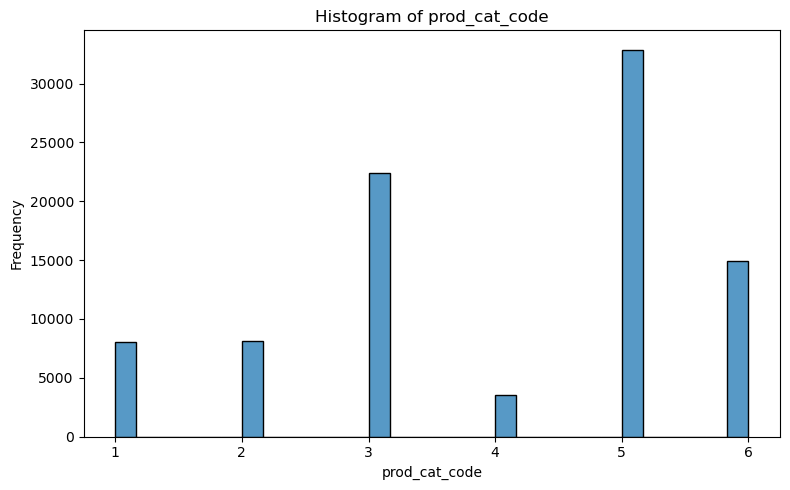

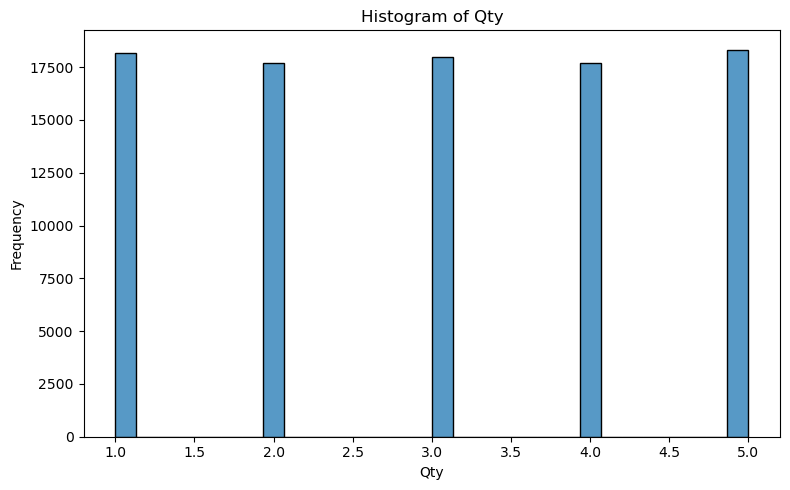

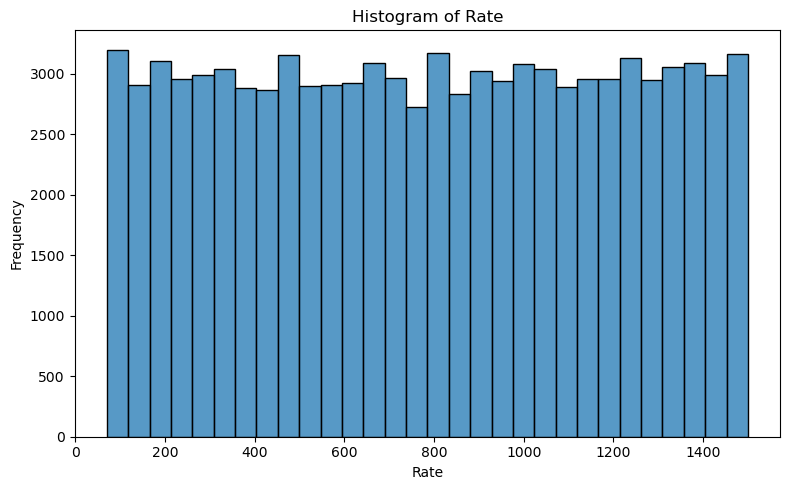

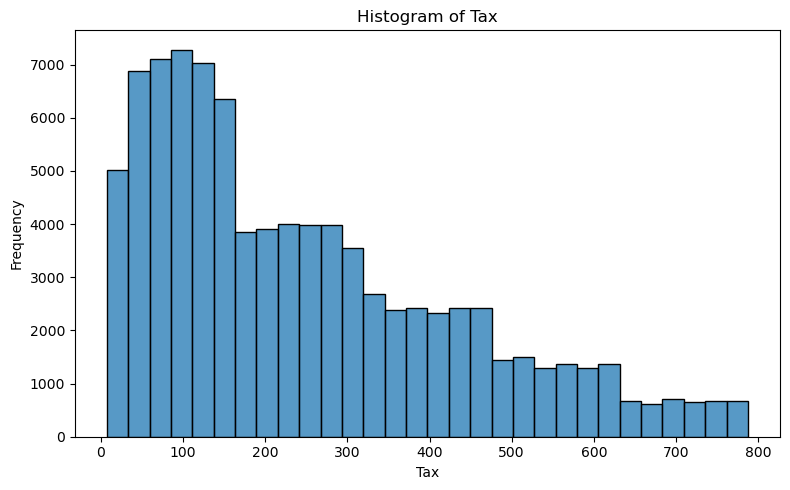

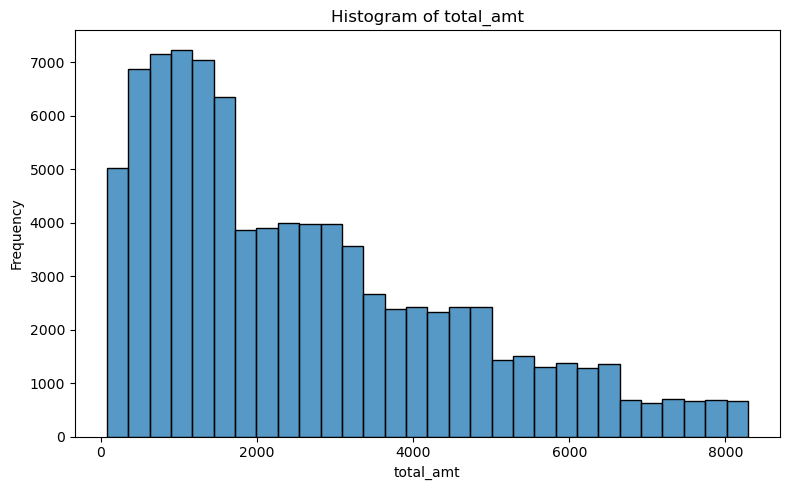

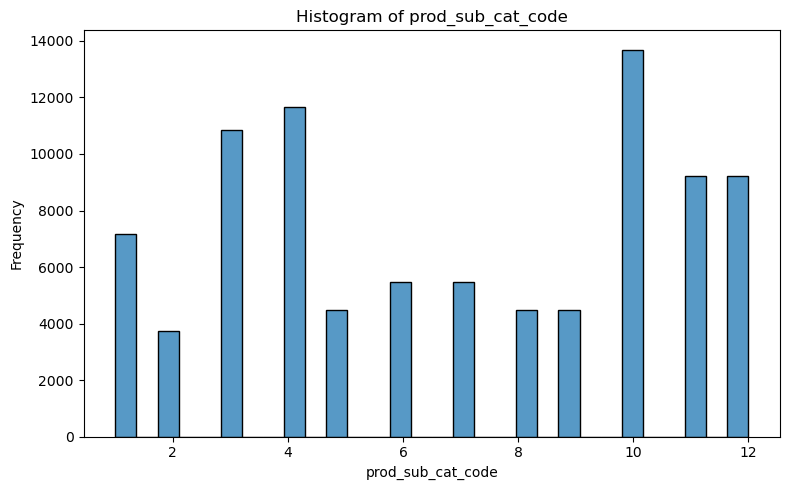

In [55]:
for i in cont_cols:
    plt.figure(figsize=(8,5))

    sns.histplot(df_cust_final[i], bins=30, kde=False)

    plt.title(f"Histogram of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(f"images/{i}_histogram.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()

#### frequency bars for categorical variables

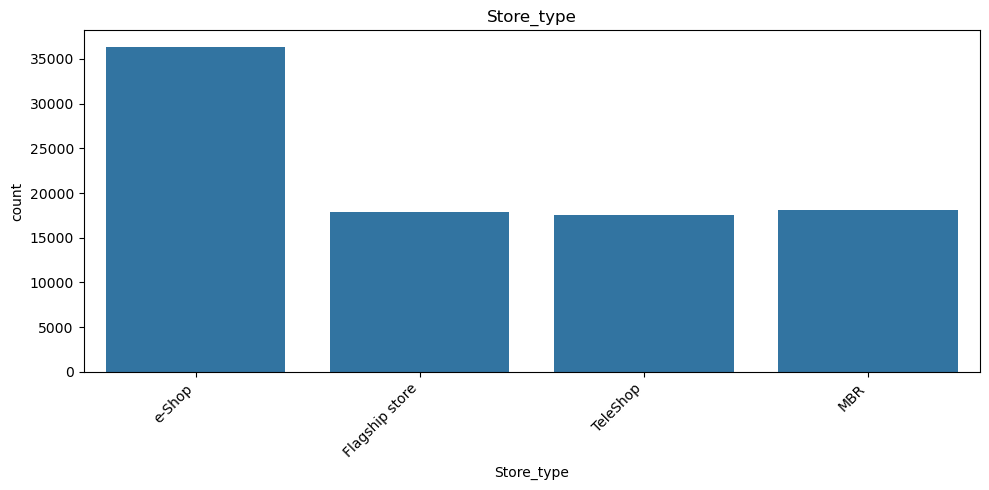

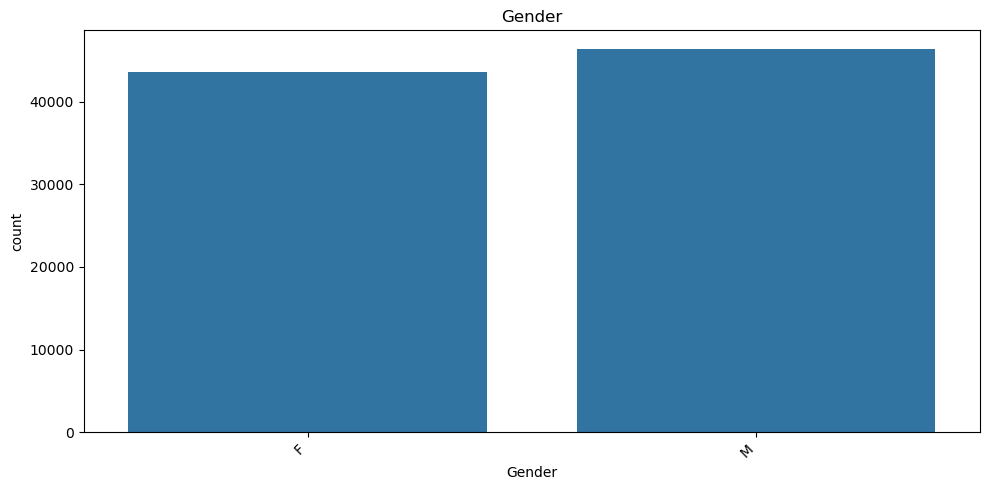

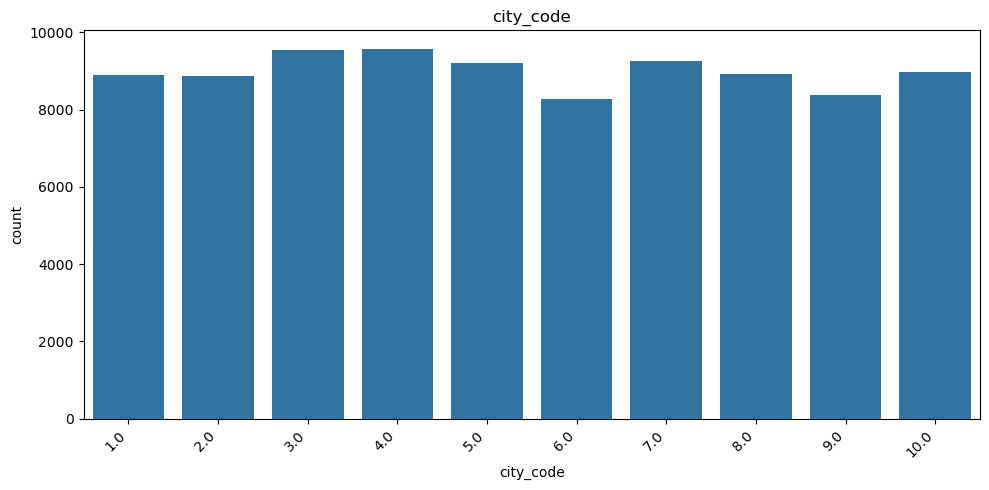

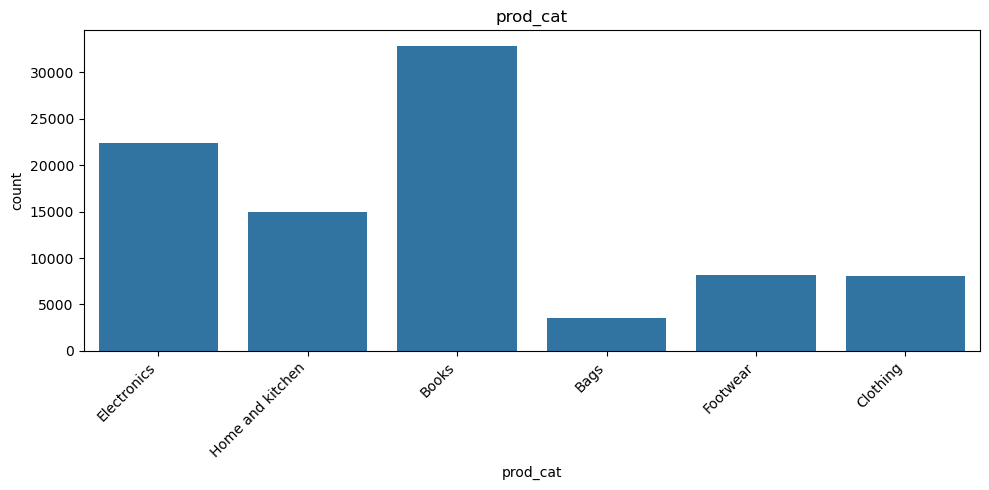

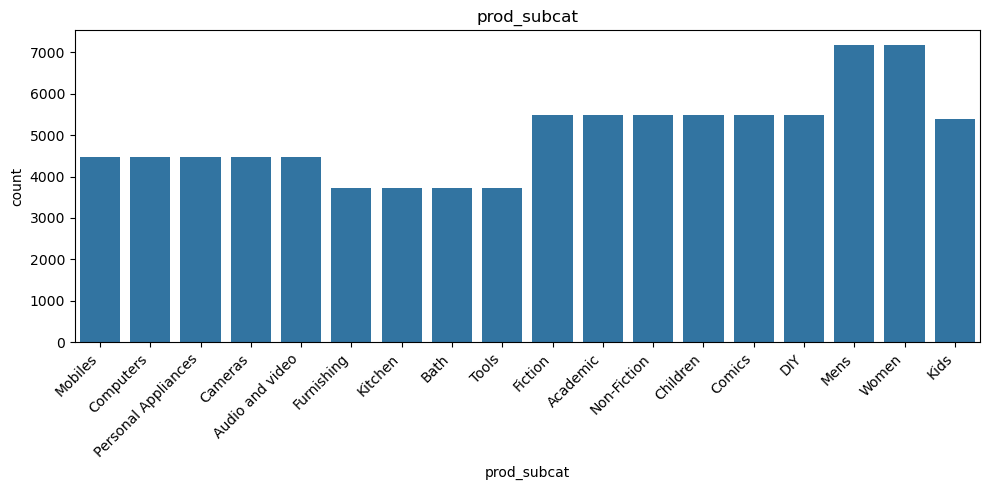

In [56]:
for i in cat_cols:
    plt.figure(figsize=(10,5))

    sns.countplot(x=df_cust_final[i])

    plt.xticks(rotation=45, ha='right')
    plt.title(i)

    plt.tight_layout()

    plt.savefig(f"images/{i}_countplot.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()

In [30]:
start_date = df_cust_final['tran_date'].min()
end_date = df_cust_final['tran_date'].max()
print("Transaction data available from :", start_date)
print("Transaction data avvailable until :", end_date)
print("Time period", end_date - start_date)

Transaction data available from : 2011-01-25 00:00:00
Transaction data avvailable until : 2014-02-28 00:00:00
Time period 1130 days 00:00:00


In [31]:
neg_txn_cnt = (df_cust_final['total_amt'] < 0).sum()
print(neg_txn_cnt)

9294


In [32]:
df_cust_final.head(2)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
0,80712190438,270351,2014-02-28,1,1,-5,-772,405.3,-4265.3,e-Shop,1981-09-26,M,5.0,Clothing,4,Mens
1,80712190438,270351,2014-02-28,1,1,-5,-772,405.3,-4265.3,e-Shop,1981-09-26,M,5.0,Clothing,1,Women


In [33]:
df_cust_final = df_cust_final[(df_cust_final['Qty'] > 0) & (df_cust_final['total_amt'] > 0)]

In [34]:
df_cust_final.head(1)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
45,29258453508,270384,2014-02-20,5,3,5,1497,785.925,8270.925,e-Shop,1973-05-11,F,8.0,Electronics,4,Mobiles


In [35]:
pd.crosstab(df_cust_final['prod_cat'],df_cust_final['Gender']).T

prod_cat,Bags,Books,Clothing,Electronics,Footwear,Home and kitchen
Gender,,,,,,
F,1780,15942,3858,10670,4140,7236
M,1798,16950,4164,11755,3981,7688


In [36]:
city_cust = df_cust_final.groupby("city_code")["cust_id"].nunique()
city_cust

/var/folders/5y/qkf24lcj4hlg6f2hqrpqmw9h0000gn/T/ipykernel_31549/3448689358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_cust = df_cust_final.groupby("city_code")["cust_id"].nunique()


city_code
1.0     535
2.0     546
3.0     576
4.0     569
5.0     570
6.0     516
7.0     563
8.0     551
9.0     532
10.0    546
Name: cust_id, dtype: int64

In [37]:
max_city = city_cust.idxmax()
max_count = city_cust.max()
print("City with maximum customers", max_city)
print("Number of customers", max_count)

City with maximum customers 3.0
Number of customers 576


In [38]:
total_customers = df_cust_final["cust_id"].nunique()

percentage = (max_count / total_customers) * 100

print("Percentage of customers from that city:", round(percentage, 2), "%")

Percentage of customers from that city: 10.46 %


In [39]:
print(df_cust_final['city_code'].isnull().sum())

36


In [40]:
df_cust_final.dropna(inplace=True)

/var/folders/5y/qkf24lcj4hlg6f2hqrpqmw9h0000gn/T/ipykernel_31549/705006601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cust_final.dropna(inplace=True)


In [41]:
print(df_cust_final['city_code'].isnull().sum())

0


In [42]:
df_cust_final.head(2)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat
45,29258453508,270384,2014-02-20,5,3,5,1497,785.925,8270.925,e-Shop,1973-05-11,F,8.0,Electronics,4,Mobiles
46,29258453508,270384,2014-02-20,5,3,5,1497,785.925,8270.925,e-Shop,1973-05-11,F,8.0,Electronics,5,Computers


In [43]:
store_summary = df_cust_final.groupby('Store_type')[['total_amt','Qty']].sum()

top_value = store_summary.sort_values(by='total_amt',ascending=False)
top_stores = store_summary.sort_values(by='Qty', ascending=False)

print("--- Top Store by Value ---")
print(top_value[['total_amt']].head(1))

print("\n--- Top Store by Quantity ---")
print(top_stores[['Qty']].head(1))

--- Top Store by Value ---
              total_amt
Store_type             
e-Shop      96044268.45

--- Top Store by Quantity ---
               Qty
Store_type        
e-Shop      109779


In [44]:
filtered_df = df_cust_final[
    (df_cust_final['Store_type'] == 'Flagship store') &
    (df_cust_final['prod_cat'].isin(['Electronics','Clothing']))
]
total_earned = filtered_df['total_amt'].sum()

print(f"Total amount earned from Electronics & Clothing: ₹{total_earned:,.2f}")

Total amount earned from Electronics & Clothing: ₹16,526,266.18


In [45]:
filtered_male_df = df_cust_final[
    (df_cust_final['Gender'] == 'M') &
    (df_cust_final['prod_cat'] == 'Electronics')
]

total_earned_from_male = filtered_male_df['total_amt'].sum()

print(f"Total amount earned from Male customer in Electronics category: ₹{total_earned_from_male:,.2f}")

Total amount earned from Male customer in Electronics category: ₹31,549,368.82


In [46]:
pos_trans = df_cust_final[df_cust_final['total_amt'] > 10]

cust_trans_cnt = pos_trans.groupby('cust_id')['transaction_id'].nunique()

freq_cust = cust_trans_cnt[cust_trans_cnt > 10]

result_cnt = freq_cust.count()

print(f"Number of customers with more than 10 unique transactions: {result_cnt}")

Number of customers with more than 10 unique transactions: 6


In [47]:
ref_date = pd.Timestamp('today').normalize()

df_cust_final['Age'] = (ref_date - df_cust_final['DOB']).dt.days / 365.25

age_filtered_df = df_cust_final[
    (df_cust_final['Age'] >= 25) &
    (df_cust_final['Age'] <= 35)
]

/var/folders/5y/qkf24lcj4hlg6f2hqrpqmw9h0000gn/T/ipykernel_31549/3096097374.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cust_final['Age'] = (ref_date - df_cust_final['DOB']).dt.days / 365.25


In [48]:
df_cust_final.head(2)

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,DOB,Gender,city_code,prod_cat,prod_sub_cat_code,prod_subcat,Age
45,29258453508,270384,2014-02-20,5,3,5,1497,785.925,8270.925,e-Shop,1973-05-11,F,8.0,Electronics,4,Mobiles,53.084189
46,29258453508,270384,2014-02-20,5,3,5,1497,785.925,8270.925,e-Shop,1973-05-11,F,8.0,Electronics,5,Computers,53.084189


In [49]:
total_spend_cats = age_filtered_df[age_filtered_df['prod_cat'].isin(['Electronics', 'Books'])]['total_amt'].sum()

print(f"Total spent on Electronics & Books: ₹{total_spend_cats:,.2f}")

Total spent on Electronics & Books: ₹10,119,778.95


In [50]:
start_date = '2014-01-01'
end_date = '2014-03-01'

date_mask =  (age_filtered_df['tran_date'] >= start_date) & (age_filtered_df['tran_date'] <= end_date)
total_amt_date = age_filtered_df[date_mask]['total_amt'].sum()

print(f"Total amount spend btw 1st Jan, 2014 to 1st Mar, 2014: ₹{total_amt_date:,.2f}")

Total amount spend btw 1st Jan, 2014 to 1st Mar, 2014: ₹836,433.06
